# Scale up the Gauss-Newton for much large problems using the new construction 

See 'toshow' notebook for a demonstration of what I'm trying to rewrite in a more streamlined verison. 

In [1]:
from timeit import timeit

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_default_matmul_precision', 'highest')
import jax.numpy as jnp
from typing import Sequence
import flax.linen as nn
from flax.training import train_state
import optax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import itertools
from jax.scipy.linalg import block_diag

# For viz
import treescope
treescope.basic_interactive_setup(
    autovisualize_arrays=True,
    abbreviation_threshold=2, 
)
treescope.register_as_default()


## Module definition

We're doing just a simple MLP with *differing* dimensions, but also be able to store the global adjoints.

However, I found a much easier solution without resorting to append adjoints, by using the Linen `perturb`

### Old adjoint code; should fold away


In [2]:
def append_adjoints(adjoints):
    # print(adjoints)
    global_adjoints.append(adjoints)

class AdjointHook(nn.Module):
    """
    A wrapper module that applies a custom VJP to any given layer
    to capture its incoming gradient (adjoint) during the backward pass.
    """
    layer: nn.Module  # The layer to wrap

    @nn.compact
    def __call__(self, *args, **kwargs):
        # Define the function to which we'll attach the custom VJP
        @jax.custom_vjp
        def layer_with_hook(params, *args, **kwargs):
            return self.layer.apply(params, *args, **kwargs)

        def layer_fwd(params, *args, **kwargs):
            output = self.layer.apply(params, *args, **kwargs)
            return output, (params, args, kwargs)

        def layer_bwd(res, g):
            params, args, kwargs = res

            # Calculate the VJP of the original wrapped layer
            # This computes the gradients w.r.t. params and inputs
            _, vjp_fun = jax.vjp(
                lambda p, *a, **kw: self.layer.apply(p, *a, **kw), params, *args, **kwargs
            )
            
            # The VJP function returns a tuple of gradients
            grad_params, *grad_args = vjp_fun(g)

            # Need to store here
            global_adjoints.append(grad_args[0])
            # jax.debug.callback(append_adjoints, grad_args[0])

            return (grad_params,) + tuple(grad_args)

        # Attach the custom forward and backward functions
        layer_with_hook.defvjp(layer_fwd, layer_bwd)
        
        # Get the parameters for the wrapped layer
        layer_params = self.param('wrapped_layer', self.layer.init, *args, **kwargs)

        return layer_with_hook(layer_params, *args, **kwargs)


## MLP code

Just the models; note the self.perturb in the layers.

In [3]:
class MLP_Layer(nn.Module):
    num_units: int
    def setup(self):
        self.dense1 = nn.Dense(self.num_units, bias_init=nn.initializers.normal(stddev=0.01))
        self.dense2 = nn.Dense(self.num_units, bias_init=nn.initializers.normal(stddev=0.01))
    def __call__(self, x):
        f = self.dense1(x)
        f = nn.tanh(f)
        f = self.dense2(f)
        return f 

# Define the MLP module
class MLP(nn.Module):
    features: Sequence[int]
    
    def setup(self):
        layers = []
        for _, dim in enumerate(self.features):
            layers.append(
                # This AdjointHook is not needed anymore
                # AdjointHook(MLP_Layer(
                #     num_units=dim
                # ))
                MLP_Layer(
                    num_units=dim
                )

            )
        self.layers = tuple(layers)

    def __call__(self, x: jnp.ndarray):
        self.sow('intermediates', f'layer_{0}_output', x)
        for i, layer in enumerate(self.layers):
            x = self.perturb(f'layer_{i+1}', x)
            x = layer(x)
            self.sow('intermediates', f'layer_{i+1}_output', x)
        return x



In [4]:
n = 1
n_samples = 5

X = jax.random.normal(jax.random.PRNGKey(0), (n_samples, n))

key = jax.random.PRNGKey(0)
model = MLP(features=[16, 16, 16, 1])
params = model.init(key, jnp.ones((1, n))) # Notice here that params has "perturbations" in it.
params, perturbations = params['params'], params['perturbations']
output, intermediates = model.apply(
    {'params': params, 'perturbation': perturbations}, X, mutable=['intermediates']
)
intermediates

{'intermediates': {'layer_0_output': (Array([[-0.20584214],
          [-0.78476578],
          [ 1.81608667],
          [ 0.18784401],
          [ 0.08086788]], dtype=float64),),
  'layer_1_output': (Array([[ 0.37472106, -0.0183461 ,  0.01328909,  0.16798535,  0.43089222,
           -0.30693518,  0.22571832, -0.30866726, -0.18189163, -0.15393123,
           -0.01555915,  0.07979895, -0.02856488,  0.01295473, -0.21451503,
           -0.21427558],
          [ 1.06230197, -0.09578069, -0.25601321,  0.3734708 ,  1.23309046,
           -0.872992  ,  0.39282997, -0.74926887, -0.23459434, -0.50430461,
            0.1310168 ,  0.21325251, -0.06385233,  0.05788874, -0.68814218,
           -0.47988586],
          [-1.60330085,  0.26195996,  0.87910707, -0.44225332, -1.73184283,
            1.22386753, -0.18709677,  0.96886694, -0.06147619,  0.941112  ,
           -0.41652493, -0.26417879,  0.00196409, -0.13081218,  0.99599789,
            0.56379792],
          [-0.35745457,  0.04369738, -0.04633132, -0.15970878, -0.39302458,
            0.31630191, -0.21840428,  0.29010525,  0.12403027,  0.16173411,
            0.03930047, -0.117626  ,  0.01945454,  0.01399442,  0.22025749,
            0.19183511],
          [-0.16258648,  0.02694213, -0.03464303, -0.07376894, -0.17281727,
            0.15032915, -0.10309702,  0.13235633,  0.04542163,  0.07729622,
            0.02755541, -0.06571797,  0.0063016 ,  0.01434032,  0.10342887,
            0.08515243]], dtype=float64),),
  'layer_2_output': (Array([[ 0.1481997 ,  0.07336148, -0.07443138, -0.11020859,  0.06805077,
            0.06489227, -0.02695651, -0.11780945, -0.21947451,  0.09717435,
            0.00441109, -0.10037402, -0.14395331,  0.03523642,  0.42888424,
            0.40336177],
          [ 0.37479997,  0.17334193, -0.18196249, -0.02044389,  0.10262955,
            0.39464048,  0.04558771, -0.50139743, -0.50439425,  0.16102696,
            0.08770454, -0.07504949, -0.40046522,  0.01807568,  1.14459023,
            0.87072265],
          [-0.45114488, -0.27518519,  0.19706578, -0.28564084, -0.11742591,
           -0.76970155, -0.12082445,  0.84530577,  0.65292318, -0.02581197,
           -0.24038018, -0.1288969 ,  0.50280201,  0.04130908, -1.62366526,
           -1.00689894],
          [-0.13104509, -0.06897612,  0.08393341,  0.05520403, -0.09738782,
           -0.11761099, -0.00739246,  0.12512212,  0.21213569, -0.08874265,
            0.01070489,  0.0798278 ,  0.0612098 , -0.00720548, -0.40418328,
           -0.34939151],
          [-0.05641404, -0.03299233,  0.04175265,  0.01563999, -0.0558729 ,
           -0.06653851, -0.01089938,  0.05906128,  0.09975656, -0.03993566,
            0.01128173,  0.0351167 ,  0.00547513,  0.00339812, -0.18511307,
           -0.1535554 ]], dtype=float64),),
  'layer_3_output': (Array([[ 0.20608715, -0.03617954, -0.0018666 , -0.33558353,  0.14485873,
            0.07143309, -0.15990862, -0.11590365,  0.38929444, -0.02327887,
           -0.23255364,  0.10049807,  0.28360374,  0.0793683 ,  0.11321332,
            0.12349473],
          [ 0.39967828, -0.08188847,  0.00438871, -0.76054262,  0.26629225,
            0.32495829, -0.50445553, -0.2405441 ,  0.89722406, -0.15798532,
           -0.63203676,  0.39890068,  0.72747524,  0.06253925,  0.09447694,
            0.40736153],
          [-0.46693583,  0.09861622,  0.01325059,  0.87934198, -0.25879654,
           -0.51507034,  0.67114899,  0.25646772, -1.02321697,  0.33168995,
            0.83676474, -0.62155884, -0.96330495,  0.09635351,  0.07782001,
           -0.54993761],
          [-0.21477188,  0.0085737 ,  0.04451314,  0.298311  , -0.13528759,
           -0.09747578,  0.11144258,  0.09478716, -0.32173014,  0.09099075,
            0.20926242, -0.09023362, -0.26389101, -0.02337681, -0.04260352,
           -0.08902324],
          [-0.106707  , -0.003484  ,  0.03366405,  0.13290401, -0.06401553,
           -0.05089862,  0.03741555,  0.04029548, -0.13497364,  0.06044666,
            0.09213258, -0.03838093

## Global adjoints

For now, we simply use the `jax.jacobian` rather than a clever thing; a bit larger memory footprint but the inversion is the time killer.

In [5]:
jacobian = jax.jacobian(model.apply, argnums=0)({'params': params, 'perturbation': perturbations}, X)['params']
flattened, _ = jax.tree.flatten(
    jacobian
)

# Reshape each leaf to (n_samples, n, -1) to flatten the parameter dimensions
reshaped_leaves = [leaf.reshape(n_samples * model.features[-1], 1, -1) for leaf in flattened]
aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
J = aggregated_array.reshape((n_samples * model.features[-1], -1))
treescope.display(J)

In [6]:
global_adjoints = []

# To grab the gradient wrt to the adjoints/residuals, we take the Jacobian wrt to the perturbations!
jacobian = jax.jacobian(
    lambda params, perturbations, X: model.apply({'params': params, 'perturbations': perturbations}, X), argnums=1
)(params, perturbations, X)
flattened, _ = jax.tree.flatten(
    jacobian
)
# It's weird that the perturbations are this dimensions, but it's easy to reshape them to what we need
together = [jnp.squeeze(leaf, axis=2).reshape((leaf.shape[0] * leaf.shape[1], -1)) for leaf in flattened]
global_adjoints = [
    block_diag(*jnp.split(leaf, n_samples, axis=0)) for leaf in together
]

global_adjoints.append(jnp.eye(J.shape[0]))


In [7]:
global_adjoints

[Array([[0.8120546 , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.3367429 , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.05492875, 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.83999759, 0.        ],
        [0.        , 0.        , 0.        , 0.        , 1.00065395]],      dtype=float64),
 Array([[-0.08306713,  0.25248503,  0.12263174,  0.36239401, -0.5488152 ,
         -0.59272542,  0.0533896 ,  0.35137929, -0.68638867, -0.20618915,
         -0.05083603, -0.87290143, -0.48808844,  0.14626826,  0.11990032,
          0.42663482,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        , -0.00330989,  0.16581259,  0.06931312,  0.22969486,
         -0.36063561, -0.37581733,  0.05077802,  0.15833154, -0.48474297,
         -0.2072018 ,  0.01798846, -0.60493164, -0.41233786,  0.09599063,
          0.04747455,  0.35379421,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.00270676,  0.09851396, -0.03560683,
          0.16218801, -0.2437468 , -0.20814524,  0.02659794,  0.06319498,
         -0.29170995, -0.16471109, -0.01046889, -0.35086589, -0.24187623,
          0.04262517,  0.03210628,  0.19813231,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ,  0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,

### Layer by Layer

Now need a good way of extracting the layer by layer. Might be better to preprocess, and store?

In [8]:
prediction, intermediates = model.apply({'params': params}, X, mutable=['intermediates'])

def get_layer_params(model: nn.Module, params: dict, layer_num: int, intermediates: jnp.ndarray):
    """
    Given the MLP model from above; extract out the layer, take the
    """
    layer = MLP_Layer(num_units=model.features[layer_num])

    def apply_layer(params):
        return layer.apply(
            params,
            intermediates['intermediates'][f'layer_{layer_num}_output'][0]
        )
    k_i = jax.jacrev(apply_layer)
    flattened, _ = jax.tree.flatten(
            k_i({'params': params[f'layers_{layer_num}']})
    )
    reshaped_leaves = [leaf.reshape(leaf.shape[0] * leaf.shape[1], -1) for leaf in flattened]
    aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1) #.reshape(n * n_samples, -1)

    return aggregated_array

# print(model.features)
# print(params[f'layers_{0}'])
get_layer_params(model, params, 0, intermediates)

Array([[-0.11874206,  0.11179129, -0.28962287, ...,  0.        ,
         0.        ,  0.        ],
       [-0.36340782, -0.31360367, -0.34346586, ...,  0.        ,
         0.        ,  0.        ],
       [-0.4400771 ,  0.06555492,  0.4717927 , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.02442009, -0.34962487,  0.16541187, ..., -0.17554004,
         0.        ,  0.        ],
       [ 0.00284293, -0.2772753 ,  0.17397851, ...,  0.        ,
        -0.17554004,  0.        ],
       [ 0.03498695, -0.42741683, -0.40635294, ...,  0.        ,
         0.        , -0.17554004]], dtype=float32)

In [9]:
k_list = []
for l in range(len(model.features)):
    k_list.append(get_layer_params(model, params, l, intermediates))


In [10]:
k_list

[Array([[-0.11874206,  0.11179129, -0.28962287, ...,  0.        ,
          0.        ,  0.        ],
        [-0.36340782, -0.31360367, -0.34346586, ...,  0.        ,
          0.        ,  0.        ],
        [-0.4400771 ,  0.06555492,  0.4717927 , ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [-0.02442009, -0.34962487,  0.16541187, ..., -0.17554004,
          0.        ,  0.        ],
        [ 0.00284293, -0.2772753 ,  0.17397851, ...,  0.        ,
         -0.17554004,  0.        ],
        [ 0.03498695, -0.42741683, -0.40635294, ...,  0.        ,
          0.        , -0.17554004]], dtype=float32),
 Array([[-0.40647772, -0.1352841 ,  0.0798846 , ...,  0.        ,
          0.        ,  0.        ],
        [-0.06212388, -0.05481514, -0.00107392, ...,  0.        ,
          0.        ,  0.        ],
        [-0.02166923,  0.17698906, -0.17937757, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.19984265,  0.23902126, -0.0781607 , ...,  0.06535938,
          0.        ,  0.        ],
        [-0.05026431,  0.07260976,  0.10935497, ...,  0.        ,
          0.06535938,  0.        ],
        [ 0.04200736, -0.22986785, -0.02667057, ...,  0.        ,
          0.        ,  0.06535938]], dtype=float32),
 Array([[ 0.11420652, -0.2764056 , -0.35122022, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.15529217, -0.2746531 ,  0.11265284, ...,  0.        ,
          0.        ,  0.        ],
        [-0.10181104, -0.5387552 , -0.31014872, ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.03827905,  0.04962991, -0.20230654, ..., -0.00965171,
          0.        ,  0.        ],
        [-0.27651608,  0.14215887, -0.05181526, ...,  0.        ,
         -0.00965171,  0.        ],
        [ 0.3938302 , -0.1641964 , -0.2334014 , ...,  0.        ,
          0.        , -0.00965171]], dtype=float32),
 Array([[ 1.3857062 ,  0.28557625, -0.05013421, -0.00258655, -0.46502018,
          0.20073165,  0.09898527, -0.22158636, -0.16060841,  0.5394477 ,
         -0.03225767, -0.32225102,  0.1392608 ,  0.39299145,  0.10998114,
          0.15688041,  0.17112741,  1.        , -0.11583232],
        [ 1.2508386 ,  0.49993303, -0.10242926,  0.00548956, -0.95131606,
          0.33308864,  0.40647036, -0.6309925 , -0.30088186,  1.1222825 ,
         -0.19761415, -0.790576  ,  0.49896038,  0.90995413,  0.07822651,
          0.1181754 ,  0.50954354,  1.        , -0.3308156 ],
        [ 1.0707065 , -0.4999512 ,  0.10558903,  0.01418749,  0.9415172 ,
         -0.27709514, -0.5514891 ,  0.71860355,  0.27460164, -1.0955651 ,
          0.35514256,  0.8959294 , -0.6655071 , -1.0314169 ,  0.10316633,
          0.08332239, -0.58882177,  1.        ,  0.48753244],
        [ 1.3710438 , -0.29446164,  0.01175492,  0.06102946,  0.40899742,
         -0.1854852 , -0.13364355,  0.15279265,  0.12995735, -0.44110608,
          0.1247523 ,  0.28690794, -0.12371425, -0.36180612, -0.03205062,
         -0.05841129, -0.12205476,  1.        ,  0.15445513],
        [ 1.3946322 , -0.14881702, -0.0048589 ,  0.04694897,  0.1853522 ,
         -0.08927812, -0.07098485,  0.05218093,  0.05619737, -0.18823858,
          0.08430086,  0.12849106, -0.05352728, -0.16856654,  0.00323515,
         -0.00457689, -0.04258554,  1.        ,  0.08403637]],      dtype=float32)]

## Let's verify again that the Jacobian can be computed like this

In [11]:
print(model.features, X.shape)
J

[16, 16, 16, 1] (5, 1)


Array([[-0.69501144, -0.42049795, -0.2728021 , ...,  0.17112741,
         1.        , -0.11583232],
       [-0.321322  , -0.27100298, -0.14790376, ...,  0.50954354,
         1.        , -0.3308156 ],
       [-0.04344603, -0.12748982, -0.01864021, ..., -0.58882177,
         1.        ,  0.48753244],
       [-0.69898504, -0.41999644, -0.27109146, ..., -0.12205476,
         1.        ,  0.15445513],
       [-0.7559469 , -0.45416406, -0.27895093, ..., -0.04258554,
         1.        ,  0.08403637]], dtype=float32)

In [12]:
# Size of (n \times k) \times (n \times k)
sum_mat = jnp.eye(J.shape[0])
lamb = 0.1

# For each layer
for i in range(len(model.features)):
    # Each dgdt item is (n \times k) \times (p_i) where p_i
    # is parameter of that layer
    middle = k_list[i] @ k_list[i].T
    # Adjoints is really scaling as n * k**2
    sum_mat += global_adjoints[i+1] @ middle @ global_adjoints[i+1].T / lamb


print(
    jnp.linalg.norm(sum_mat - (jnp.eye(J.shape[0]) + J @ J.T/lamb))
)
# sum_mat

0.00010803647109457591


In [13]:
jnp.linalg.norm(sum_mat - (jnp.eye(J.shape[0]) + J @ J.T/lamb))


Array(0.00010804, dtype=float64)

## Let's write a thing which given the two lists and the input gradient, will figure this out

In [14]:
@jax.jit # This takes list, and makes them static; can be jitted easily
def get_correction(k_list, global_adjoints, grad, lamb: float=1e-1):
    """
    Assumes grad is a vector
    """
    p_list = [k.shape[1] for k in k_list]
    p_list.insert(0, 0)
    indices = list(itertools.accumulate(p_list))
    j_shape = global_adjoints[0].shape[0]

    # Use the SMW formulation; first do Jv
    aux_var = jnp.zeros(j_shape)
    for i in range(len(model.features)):
        aux_var += global_adjoints[i+1] @ (k_list[i] @ grad[indices[i]:indices[i+1]])

    # Calculate I + 1 / lamb JJ^T and get its inverse
    sum_mat = jnp.eye(j_shape)
    print(sum_mat.shape)
    for i in range(len(model.features)):
        sum_mat += global_adjoints[i+1] @ k_list[i] @ k_list[i].T @ global_adjoints[i+1].T / lamb
    aux_var = jnp.linalg.solve(sum_mat, aux_var)

    # Finally do J^T v and scale
    out = jnp.concat([k_list[i].T @ (global_adjoints[i+1].T @ aux_var) for i in range(len(model.features))]) / (lamb ** 2)

    # Don't forget the 1/lambda I
    return -out + grad / lamb

@jax.jit
def test_normal_inverse(J, grad, lamb: float=1e-1):
    return jnp.linalg.solve(jnp.eye(J.shape[1]) + lamb * J.T @ J, grad)

grad = jnp.arange(J.shape[1],) * 2
test_normal_inverse(J, grad, lamb=1e-2)
my_correct = get_correction(k_list, global_adjoints, grad, lamb=1e1)
my_correct = get_correction(k_list, global_adjoints, grad, lamb=1e0)
my_correct = get_correction(k_list, global_adjoints, grad, lamb=1e-2)
jnp.linalg.norm(jnp.linalg.solve(jnp.eye(J.shape[1]) * 1e-2 + J.T @ J, grad) - my_correct) / (my_correct.T @ my_correct)

(5, 5)


Array(1.94370863e-12, dtype=float64)

In [15]:
@timeit 
get_correction(k_list, global_adjoints, grad, lamb=1e0)

171 μs ± 3.81 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [16]:
%timeit test_normal_inverse(J, grad, lamb=1e-2)

26.7 ms ± 826 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [17]:
type(get_correction)

jaxlib._jax.PjitFunction

## With the above now we need to solve some problems

Let's try to learn a simple functional regression problem;

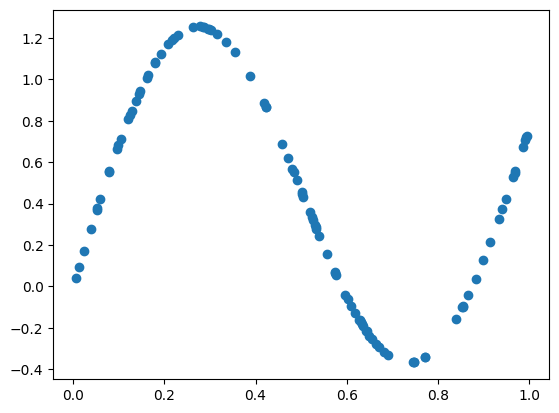

In [24]:
num_samples = 100
X = jax.random.uniform(jax.random.PRNGKey(0), (num_samples, 1), minval=0, maxval=1)
y = jnp.sin(2 * jnp.pi * X) + jnp.tanh(X)

plt.scatter(X, y)

In [25]:
def train_model_sgd(X_train, y_train, model, params, learning_rate, num_epochs):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(
        apply_fn=model.apply, params=params['params'], tx=optimizer
    )

    @jax.jit
    def train_step(state, batch_X, batch_y):
        def loss_fn(params):
            predictions = state.apply_fn(params, batch_X)
            # Mean Squared Error loss on only the first thing; the rest of the things don't matter
            loss = jnp.mean(jnp.square(predictions - batch_y))
            return loss, predictions

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, predictions), grads = grad_fn({'params': state.params})
        state = state.apply_gradients(grads=grads['params'])
        return state, loss

    losses = []
    print(f"Starting training for {num_epochs} epochs...")
    for _ in tqdm(range(num_epochs)):
        state, loss = train_step(state, X_train, y_train)
        losses.append(loss)

    return state, losses

num_epochs = 5_000

key = jax.random.PRNGKey(0)

model = MLP(features=[16, 16, 16, 1])
params = model.init(key, jnp.ones((1, 1)))

# Train the model
trained_state_sgd, sgd_losses = train_model_sgd(
    X, y, model, params, learning_rate=2e-3, num_epochs=num_epochs
)

Starting training for 5000 epochs...


  0%|          | 0/5000 [00:00<?, ?it/s]

[<matplotlib.lines.Line2D at 0x7ad9bc19a780>]

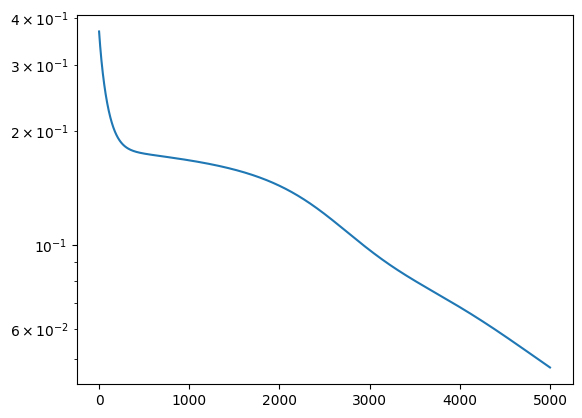

In [26]:
plt.semilogy(sgd_losses)

In [32]:
def train_model_precond(X_train, y_train, model, params, learning_rate, num_epochs):
    # Define the optimizer
    optimizer = optax.sgd(learning_rate)
    state = train_state.TrainState.create(
        apply_fn=model.apply, params=params['params'], tx=optimizer
    )

    # Grab the functions for each layer and store it in list
    # ks = []
    # for layer_num in range(len(model.features)):
    #     ks.append(k_i)

    @jax.jit
    def train_step(state, batch_X, batch_y):
        def loss_fn(params):
            predictions = state.apply_fn(params, batch_X)
            loss = jnp.mean(jnp.square(predictions - batch_y))
            return loss, predictions

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (loss, predictions), grads = grad_fn({'params': state.params})

        jacobian = jax.jacobian(
            lambda params, perturbations, batch_X:
                state.apply_fn({'params': params, 'perturbations': perturbations}, X), argnums=1
        )(state.params, params['perturbations'], X)
        flattened, _ = jax.tree.flatten(
            jacobian
        )
        together = [jnp.squeeze(leaf, axis=2).reshape((leaf.shape[0] * leaf.shape[1], -1)) for leaf in flattened]
        global_adjoints = [
            block_diag(*jnp.split(leaf, len(batch_X), axis=0)) for leaf in together
        ]
        global_adjoints.append(jnp.eye(batch_X.shape[0]))

        # Evaluate layers; refactor later
        _, intermediates = state.apply_fn(
            {'params': state.params}, batch_X, mutable=['intermediates']
        )

        k_list = []
        for layer_num in range(len(model.features)):
            layer = MLP_Layer(num_units=model.features[layer_num])
            def apply_layer(params):
                return layer.apply(
                    params,
                    intermediates['intermediates'][f'layer_{layer_num}_output'][0]
                    # intermediates['intermediates'][f'layer_{layer_num}_output'][0]
                )
            k_i = jax.jacrev(apply_layer, argnums=0)
            flattened, _ = jax.tree.flatten(
                k_i(
                {'params': state.params[f'layers_{layer_num}']}
            ))

            reshaped_leaves = [leaf.reshape(leaf.shape[0] * leaf.shape[1], -1) for leaf in flattened]
            aggregated_array = jnp.concatenate(reshaped_leaves, axis=-1)
            k_list.append(aggregated_array)

        flattened, back = jax.flatten_util.ravel_pytree(grads)
        altered = get_correction(
            k_list, global_adjoints, flattened,lamb=1e-1
        )
        grads = back(altered)

        state = state.apply_gradients(grads=grads['params'])
        return state, loss

    losses = []
    print(f"Starting training for {num_epochs} epochs...")
    for epoch in tqdm(range(num_epochs)):
        state, loss = train_step(state, X_train, y_train)
        if loss > 1e2:
            break
        losses.append(loss)

    return state, losses

num_epochs = 500
key = jax.random.PRNGKey(0)
params = model.init(key, jnp.ones((1, 1)))

# Train the model
trained_state_precond, precond_losses = train_model_precond(
    X, y, model, params, learning_rate=2e-3, num_epochs=num_epochs
)

Starting training for 500 epochs...


  0%|          | 0/500 [00:00<?, ?it/s]

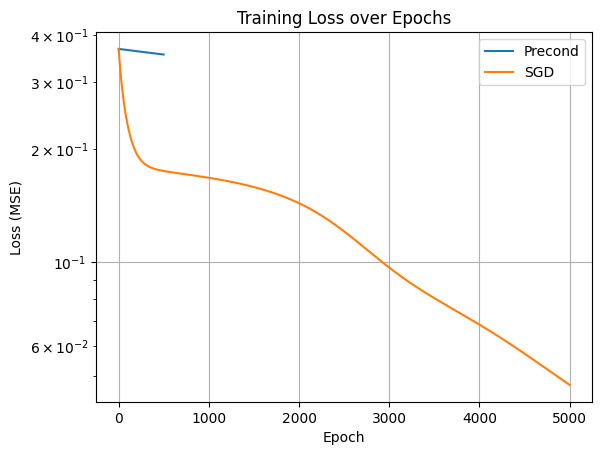

In [34]:
plt.semilogy(precond_losses,label='Precond')
plt.semilogy(sgd_losses, label='SGD')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)



In [35]:
# predicted_y = model.apply(trained_state_precond.params, X)

# # Create a figure with two subplots
# plt.figure(figsize=(12, 5))
#
# # First subplot for True vs. Predicted Data
# plt.subplot(1, 2, 1)  # 2 rows, 1 column, 1st subplot
# plt.scatter(X[:, 0], y[:, 0], marker='o', label='True Data', alpha=0.5)
# plt.scatter(X[:, 0], predicted_y[:, 0], marker='x', color='red', label='Predicted Data', alpha=0.6)
# plt.title('1D Regression Problem: True vs. Predicted Data')
# plt.xlabel('X')
# plt.ylabel('y')
# plt.legend()
# plt.grid(True)
#
# # Second subplot for Training Loss over Epochs
# plt.subplot(1, 2, 2)  # 2 rows, 1 column, 2nd subplot
# plt.semilogy(precond_losses, label='Precond')
# plt.semilogy(sgd_losses, label='SGD')
# plt.title('Training Loss over Epochs')
# plt.xlabel('Epoch')
# plt.ylabel('Loss (MSE)')
# plt.legend()
# plt.grid(True)
#
# # Show the combined plot
# plt.tight_layout()
# plt.show()